# Temperature Normal calculation Example

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from datetime import date
from patsy import dmatrix
import statsmodels.api as sm

### Read in Data

In [41]:
# Subset relevant data, add other useful columns
raw_data = pd.read_csv('../raw_sources/'+'daily_weather.csv', index_col=False, parse_dates=['date'])

temperatures = raw_data[['date', 'avg_temp', 'min_temp', 'max_temp']].copy()
temperatures['year'] = temperatures['date'].dt.year
month_order =['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
temperatures['month'] = pd.Categorical(
  temperatures['date'].dt.strftime('%b'), 
  categories=month_order, 
  ordered=True
)
temperatures['date_formatted'] = temperatures['date'].dt.strftime('%b-%d')

In [14]:
# Generates day of year index, with options for calendar year, water year, or snow season. 
# Accounts for leap years by assigning Feb 29 a value of 59.5 and shifting subsequent days back by 1.
def gen_DoY_index(x):
  mar1_day = 60
  return_value = x.dayofyear

  if x.is_leap_year:
    if x.dayofyear > mar1_day:
      return_value -= 1 
    elif x.dayofyear == mar1_day:
      return_value -= 0.5

  return (return_value - 1) % 365 + 1

temperatures['day_of_year'] = temperatures['date'].apply(gen_DoY_index)

In [15]:
# Calculate 30 year normal based on last complete decade
N_years = 30
current_year = temperatures['year'].max()
normal_end_year = int(np.floor(current_year / 10) * 10)
normal_start_year = normal_end_year - N_years + 1

data_for_normal = temperatures.loc[temperatures['year'].between(normal_start_year, normal_end_year)].copy()
print(f"Calculating normals from {normal_start_year} to {normal_end_year}")

Calculating normals from 1991 to 2020


In [ ]:
(
  data_for_normal
)

,date,avg_temp,min_temp,max_temp,year,month,day_of_year,date_formatted
7670,1991-01-01,10.4,2.2,22.9,1991,Jan,1.0,Jan-01
7671,1991-01-02,10.2,0.2,23.0,1991,Jan,2.0,Jan-02
7672,1991-01-03,11.3,2.4,17.9,1991,Jan,3.0,Jan-03
7673,1991-01-04,19.4,15.2,24.1,1991,Jan,4.0,Jan-04
7674,1991-01-05,22.4,14.3,28.1,1991,Jan,5.0,Jan-05
...,...,...,...,...,...,...,...,...
18623,2020-12-27,30.7,23.0,37.8,2020,Dec,361.0,Dec-27
18624,2020-12-28,27.0,21.9,34.7,2020,Dec,362.0,Dec-28
18625,2020-12-29,25.0,17.9,32.0,2020,Dec,363.0,Dec-29
18626,2020-12-30,25.7,19.0,32.9,2020,Dec,364.0,Dec-30


### EDA
Let's start by predicting normals for high temperatures

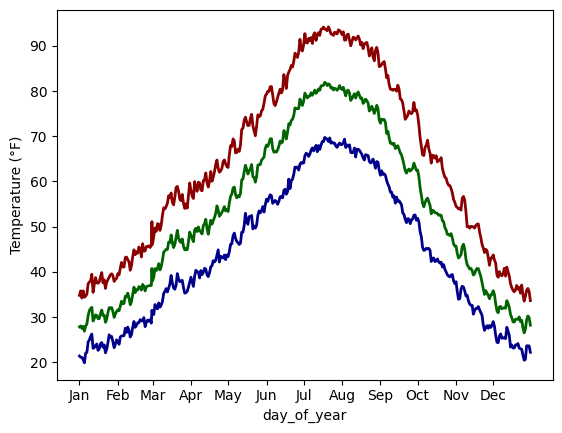

In [42]:
# Avg across all years for each day of year
all_avgs = (
  data_for_normal
  .groupby(['day_of_year'])
  .agg(
    max_temp=('max_temp', 'mean'),
    min_temp=('min_temp', 'mean'),
    avg_temp=('avg_temp', 'mean'),
  )
  .reset_index()
)

sns.lineplot(all_avgs, x='day_of_year', y='max_temp', color='darkred', linewidth=2)
sns.lineplot(all_avgs, x='day_of_year', y='min_temp', color='darkblue', linewidth=2)
sns.lineplot(all_avgs, x='day_of_year', y='avg_temp', color='darkgreen', linewidth=2)
plt.xticks(
  ticks=[1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335], 
  labels=month_order,
)
plt.ylabel('Temperature (°F)')
plt.show()

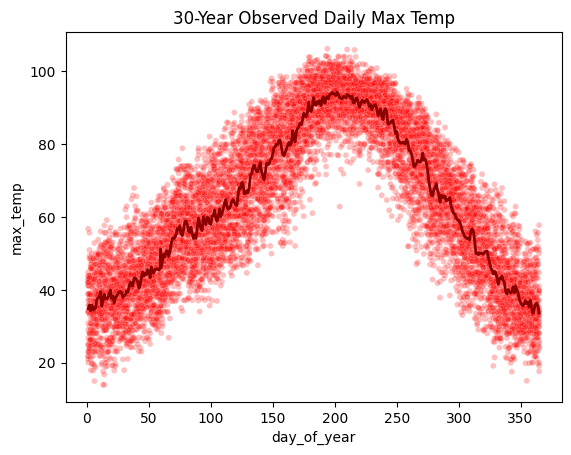

In [46]:
METRIC = 'max_temp' # high temperatures

sns.scatterplot(data_for_normal, x='day_of_year', y=METRIC, legend=None, alpha=0.25, color='red', size=3)
sns.lineplot(all_avgs, x='day_of_year', y=METRIC, color='darkred', linewidth=2)
plt.title(f'{N_years}-Year Observed Daily {METRIC.replace("_", " ").title()}')
plt.show()

### Model
Plan: Smooth out a seasonal avg curve
- CV: Find optimal knots for cyclic cubic spline
- To ensure equal number of points per day, Plan: 30-fold CV by year
- Goal: Pick smallest df where the error is minimized
- Errors tend to taper off after df=5, so this is likley limit before overfitting

                            OLS Regression Results                            
Dep. Variable:               max_temp   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                 1.041e+04
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:17:31   Log-Likelihood:                -39344.
No. Observations:               10958   AIC:                         7.870e+04
Df Residuals:                   10952   BIC:                         7.874e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

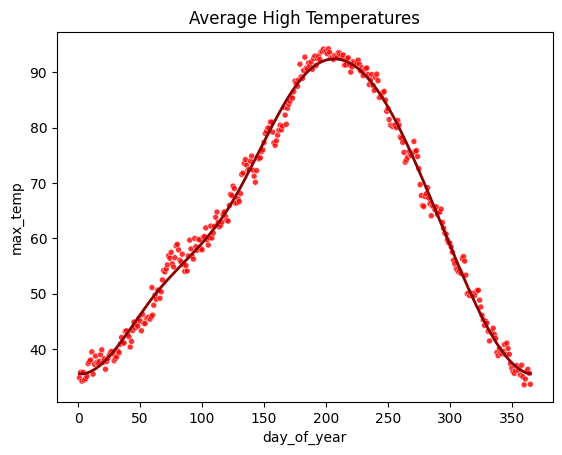

In [ ]:
# Initial Model Fit
basis_normal = dmatrix(
    "1 + cc(day_of_year, df=5, constraints='center', upper_bound=366)",
    {"day_of_year": data_for_normal['day_of_year'],},
    return_type='dataframe'
)

# Predict fitted values
model_norm = sm.OLS(data_for_normal['max_temp'], basis_normal).fit()
print(model_norm.summary())
data_for_normal['initial_prediction'] = round(model_norm.predict(basis_normal),2)

# Initial Fit
sns.scatterplot(all_avgs, x='day_of_year', y='max_temp', legend=None, alpha=0.8, color='red', size=3)
sns.lineplot(data_for_normal[data_for_normal['year']==normal_end_year], x='day_of_year', y='initial_prediction', color='darkred', linewidth=2)
plt.title('Average High Temperatures')
plt.show()

# Problem: What is the optimal number of knots to use for the spline model? Too few and we miss important variation, too many and we overfit to noise in the data. We can use cross validation to find the optimal number of knots.

Finished 2, error 7.369814831449461
Finished 3, error 7.43468345934077
Finished 4, error 7.101397634553484
Finished 5, error 7.077233500511515
Finished 6, error 7.087382363949398
Finished 7, error 7.071407465628665
Finished 8, error 7.077611223394965
Finished 9, error 7.075026049854032
Finished 10, error 7.081282605983483
Finished 11, error 7.073250118521846
Finished 12, error 7.076835915861966
Finished 13, error 7.062677670484319
Finished 14, error 7.071568854954213
Finished 15, error 7.069517503805174
Finished 16, error 7.0816089777178926
Finished 17, error 7.074600219577314
Finished 18, error 7.085751653067844
Finished 19, error 7.07990540709135
Finished 20, error 7.085360356314095
Finished 21, error 7.0844002046061325
Finished 22, error 7.094247448661326
Finished 23, error 7.077768620405719
Finished 24, error 7.0921651570726345


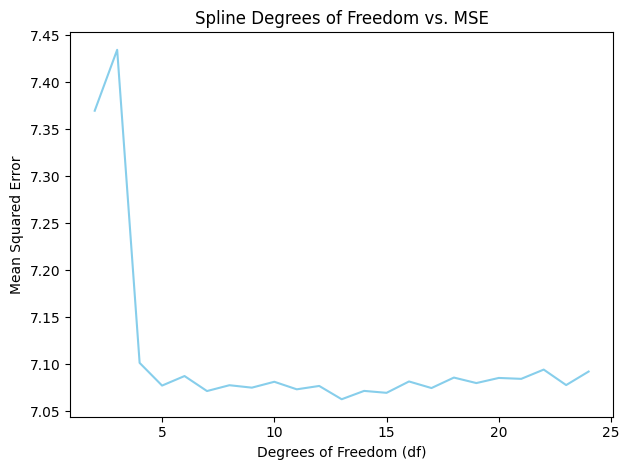

In [ ]:
# Cross validate to find optimal degrees of freedom for spline model
dfs = range(2,25)
df_errors = dict()

for df in dfs:
  errors_all_years = []
  for y in data_for_normal['year'].unique():
    cv_data = data_for_normal[data_for_normal['year']!=y].copy()
    test_data = data_for_normal[data_for_normal['year']==y].copy()

    basis_cv = dmatrix(
      f"1 + cc(day_of_year, df={df}, constraints='center', upper_bound=366)",
      {"day_of_year": cv_data['day_of_year'],},
      return_type='dataframe'
    )

    basis_test = dmatrix(
      f"1 + cc(day_of_year, df={df}, constraints='center', upper_bound=366)",
      {"day_of_year": test_data['day_of_year'],},
      return_type='dataframe'
    )
      
    model_cv = sm.OLS(cv_data['max_temp'], basis_cv).fit()
    test_data['test_prediction'] = round(model_cv.predict(basis_test,2))
    test_data['error'] = test_data['test_prediction'] - test_data[METRIC]
    mae = np.mean(abs(test_data['error']))
    # mse = mean(test_data['error']**2)
    errors_all_years.append(mae)
  
  df_errors[df] = np.mean(errors_all_years)
  print(f"Finished {df}, error {df_errors[df]}")
pd.DataFrame(df_errors.items(), columns=['df', 'error']).sort_values('error')

plt.plot(df_errors.keys(), df_errors.values(), color='skyblue')
plt.xlabel('Degrees of Freedom (df)')
plt.ylabel('Mean Squared Error')
plt.title(f'Spline Degrees of Freedom vs. MSE')
plt.tight_layout()
plt.show()

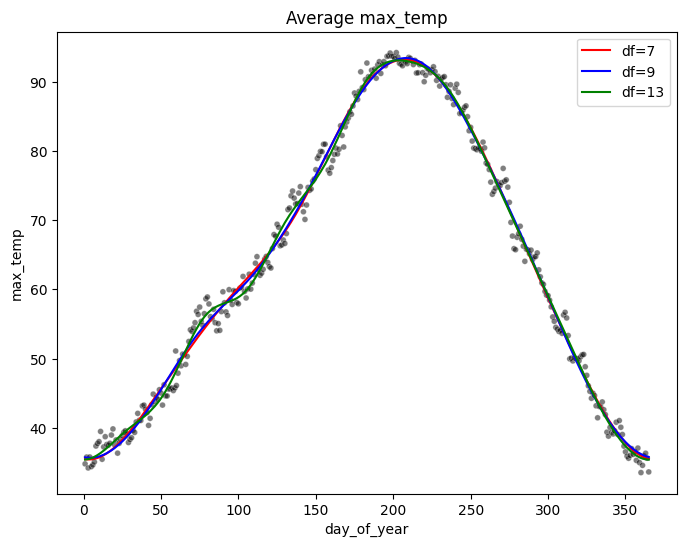

In [ ]:
# Compare knot fits for a few selected values
knots_to_display = [7,9,13]
for k in knots_to_display:
  basis = dmatrix(
    f"1 + cc(day_of_year, df={k}, constraints='center', upper_bound=366)",
    {"day_of_year": all_avgs['day_of_year'],},
    return_type='dataframe'
  )
  model = sm.OLS(all_avgs[METRIC], basis).fit()
  all_avgs[f'prediction_{k}'] = round(model.predict(basis),2)


all_avgs.sort_values('day_of_year', ascending=False)
colors = ['red', 'blue', 'green', 'darkyellow', 'green']
plt.figure(figsize=(8, 6))
sns.scatterplot(all_avgs, x='day_of_year', y=METRIC, legend=None, alpha=0.5, color='black', size=3)
for i, k in enumerate(knots_to_display):
  sns.lineplot(all_avgs, x='day_of_year', y=f'prediction_{k}', color=colors[i], linewidth=1.5, label=f'df={k}')
plt.title(f'Average {METRIC}')
plt.show()

# I will select df=7 since the other knots have marginally better fit but are more complex models that have wiggly patterns which are likely overfitting to a few warm years.

In [79]:
# Final Model
final_basis = dmatrix(
    f"1 + cc(day_of_year, df=7, constraints='center', upper_bound=366)",
    {"day_of_year": data_for_normal['day_of_year'],},
    return_type='dataframe'
)

# Predict fitted values
model = sm.OLS(data_for_normal[METRIC], final_basis).fit()
predictions = round(model.predict(final_basis),2)
data_for_normal[f'normal_{METRIC}'] = predictions

In [80]:
data_for_normal

,date,avg_temp,min_temp,max_temp,year,month,date_formatted,day_of_year,initial_prediction,normal_max_temp
7670,1991-01-01,10.4,2.2,22.9,1991,Jan,Jan-01,1.0,35.50,35.48
7671,1991-01-02,10.2,0.2,23.0,1991,Jan,Jan-02,2.0,35.49,35.45
7672,1991-01-03,11.3,2.4,17.9,1991,Jan,Jan-03,3.0,35.50,35.43
7673,1991-01-04,19.4,15.2,24.1,1991,Jan,Jan-04,4.0,35.52,35.43
7674,1991-01-05,22.4,14.3,28.1,1991,Jan,Jan-05,5.0,35.55,35.45
...,...,...,...,...,...,...,...,...,...,...
18623,2020-12-27,30.7,23.0,37.8,2020,Dec,Dec-27,361.0,35.75,35.85
18624,2020-12-28,27.0,21.9,34.7,2020,Dec,Dec-28,362.0,35.67,35.75
18625,2020-12-29,25.0,17.9,32.0,2020,Dec,Dec-29,363.0,35.61,35.66
18626,2020-12-30,25.7,19.0,32.9,2020,Dec,Dec-30,364.0,35.56,35.58


### Results

In [84]:
# Sanity Check Endpoints
(
  data_for_normal
  .groupby('date_formatted')
  .agg({'max_temp': 'mean'})
  .reset_index()
  .sort_values(by='max_temp', ascending=False)
  .tail(10)
)

,date_formatted,max_temp
83,Dec-23,35.293333
127,Jan-07,35.060000
85,Dec-25,34.976667
121,Jan-01,34.793333
126,Jan-06,34.636667
87,Dec-27,34.576667
125,Jan-05,34.386667
123,Jan-03,34.200000
91,Dec-31,33.623333
86,Dec-26,33.530000


In [ ]:
# What is avg hottest / coldest day of year on avg?

(
  data_for_normal[data_for_normal['year']==normal_end_year]
  [['day_of_year','date_formatted',f'normal_{METRIC}']]
  .sort_values(by=f'normal_{METRIC}', ascending=False)
)
(
  data_for_normal[data_for_normal['year']==normal_end_year]
  [['day_of_year','date_formatted',f'normal_{METRIC}']]
  .sort_values(by=f'normal_{METRIC}', ascending=True)
)

# Jan 3rd is the coldest max of the year
# July 26th is hottest max of the year

,day_of_year,date_formatted,normal_max_temp
18264,3.0,Jan-03,35.43
18265,4.0,Jan-04,35.43
18263,2.0,Jan-02,35.45
18266,5.0,Jan-05,35.45
18262,1.0,Jan-01,35.48
...,...,...,...
18467,205.0,Jul-24,93.18
18468,206.0,Jul-25,93.20
18471,209.0,Jul-28,93.20
18470,208.0,Jul-27,93.21


# Todo: Add quantile bounds, monthly heatmap, trend view